# Notebook 3: Baseline Model
## Multi-Layer Perceptron (MLP) on One-Hot Encoded Sequences

**Purpose:** Establish a non-convolutional deep learning baseline using a simple MLP applied to one-hot encoded pol gene sequences.

The MLP baseline:
- Uses the **same one-hot input representation** as our CNN (fair comparison)
- Has **no convolutional layers** — it cannot learn positional motifs
- Uses global average pooling to compress the sequence into a fixed-length vector

If the CNN significantly outperforms the MLP, it proves that **local spatial features** (motifs detected by convolution) are important for subtype classification — not just overall nucleotide composition.


## Import libraries

In [1]:
import os, sys, pickle, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

!pip install biopython -q


## Workspace & Environment Setup
Mounts Google Drive to access persistent project directories and configures the compute device.

In [2]:


from google.colab import drive
drive.mount('/content/drive')

projectdir = '/content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final'
processed_data = os.path.join(projectdir, 'data', 'processed')
models_dir = os.path.join(projectdir, 'models')
reports = os.path.join(projectdir, 'reports', 'figures')
os.makedirs(models_dir, exist_ok=True)
os.makedirs(reports, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4


## Data Loading
Loads the preprocessed datasets or data objects from disk for downstream tasks.

In [3]:
# Load preprocessed data from Notebook 02
with open(os.path.join(processed_data, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
idx_to_label = data['idx_to_label']
label_to_idx = data['label_to_idx']
num_classes = data['num_classes']
MAX_LENGTH = data['max_length']

print(f'Classes: {list(label_to_idx.keys())}')
print(f'Max length: {MAX_LENGTH}')
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Classes: ['A', 'B', 'C', 'D']
Max length: None
Train: 3896 | Val: 833 | Test: 835


## Import DataLoaders

In [4]:
# Import DataLoader factory from src/data_loader.py
sys.path.insert(0, os.path.join(projectdir, 'src'))
from data_loader import create_dataloaders

# Create DataLoaders from pre-split data
train_dl, val_dl, test_dl = create_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    max_length=MAX_LENGTH, encoding='onehot', batch_size=32
)

Gap-stripped: train lengths 2917–3099 bp
DataLoaders ready: train=122, val=27, test=27 batches


## Step 1: Define MLP Baseline Architecture

### Scientific Rationale
To establish a baseline for classification, we first evaluate the predictive power of **global nucleotide composition** alone.

**Methodology:**
* We utilize `AdaptiveAvgPool1d(1)` to average the entire sequence into a single global profile.
* This calculates the overall percentage of A, C, G, and T across the entire `pol` gene, completely disregarding any structural domains or sequence order.
* These 5 features are passed through a tiny Multi-Layer Perceptron (MLP).
* This baseline tests whether the overall nucleotide composition of the virus is sufficient for subtype classification, establishing a strict lower-bound before applying complex sequence-level motif detection techniques (like CNNs).


In [5]:
class HIV_MLP(nn.Module):
    """
    Baseline MLP: Evaluates global nucleotide composition across the entire sequence.
    """

    def __init__(self, num_classes, dropout=0.3):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            # Global Average Pooling: squashes the entire sequence into 1 average value per channel
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(4, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

mlp_model = HIV_MLP(num_classes).to(device)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP Baseline — Parameters: {total_params:,}")

MLP Baseline — Parameters: 180


## Step 2: Training Utilities

### Key training strategies:
- **Focal LossLoss**: Handles class imbalance by giving higher weight to rare subtypes (e.g., D)
- **AdamW optimizer**: Adam with weight decay for regularization
- **CosineAnnealingLR**: Gradually reduces learning rate for fine-grained convergence
- **Early stopping**: Prevents overfitting by monitoring validation loss
- **Gradient clipping**: Prevents exploding gradients

In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in tqdm(loader, desc='  Train', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
    return total_loss/total, correct/total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='  Val', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    return total_loss/total, correct/total

# Initiate full training pipeline with early stopping
def train_model(model, train_dl, val_dl, model_name, epochs=5, lr=3e-3):
    try:
        weights = torch.load(os.path.join(projectdir, 'data', 'processed', 'class_weights.pt')).to(device)
        import sys
        src_path = os.path.join(projectdir, 'src')
        if src_path not in sys.path:
            sys.path.append(src_path)
        from train import FocalLoss
        # Focal Loss focuses on hard-to-predict minority classes
        criterion = FocalLoss(alpha=weights, gamma=2.0)
        print('Initialized FocalLoss.')
    except FileNotFoundError:
        import sys
        src_path = os.path.join(projectdir, 'src')
        if src_path not in sys.path:
            sys.path.append(src_path)
        from train import FocalLoss
        # Focal Loss focuses on hard-to-predict minority classes
        criterion = FocalLoss(gamma=2.0)
        print('Class weights not found, using standard FocalLoss.')
    # Initialize AdamW optimizer with weight decay for regularization
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
    best_val_loss = float('inf')
    best_state = None

    print(f'\n{"="*50}\nTraining: {model_name}\n{"="*50}')
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {total_params:,}')

    for epoch in range(epochs):
        lr_now = optimizer.param_groups[0]['lr']
        t_loss, t_acc = train_epoch(model, train_dl, criterion, optimizer)
        v_loss, v_acc = eval_epoch(model, val_dl, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['lr'].append(lr_now)

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'TL: {t_loss:.4f} TA: {t_acc:.4f} | '
              f'VL: {v_loss:.4f} VA: {v_acc:.4f} | LR: {lr_now:.6f}')

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = copy.deepcopy(model.state_dict())

    if best_state:
        model.load_state_dict(best_state)
    torch.save({'state_dict': model.state_dict(), 'history': history},
               os.path.join(models_dir, f'{model_name}_best.pth'))
    print(f'Best val loss: {best_val_loss:.4f}')
    return history



## Step 3: Train MLP Baseline

In [7]:
mlp_history = train_model(mlp_model, train_dl, val_dl, 'HIV_MLP',
                          epochs=30, lr=1e-4)


Initialized FocalLoss.

Training: HIV_MLP
Parameters: 180


Epoch  1/30 | TL: 0.7791 TA: 0.6078 | VL: 0.7802 VA: 0.6303 | LR: 0.000100


Epoch  2/30 | TL: 0.7448 TA: 0.6435 | VL: 0.7615 VA: 0.6579 | LR: 0.000100


Epoch  3/30 | TL: 0.7192 TA: 0.6648 | VL: 0.7420 VA: 0.6903 | LR: 0.000099


Epoch  4/30 | TL: 0.6974 TA: 0.6810 | VL: 0.7128 VA: 0.7383 | LR: 0.000098


...

Epoch 26/30 | TL: 0.5089 TA: 0.6435 | VL: 0.5394 VA: 0.6639 | LR: 0.000008


Epoch 27/30 | TL: 0.5024 TA: 0.6389 | VL: 0.5402 VA: 0.6963 | LR: 0.000005


Epoch 28/30 | TL: 0.5250 TA: 0.6430 | VL: 0.5391 VA: 0.6783 | LR: 0.000003


Epoch 29/30 | TL: 0.5250 TA: 0.6376 | VL: 0.5425 VA: 0.6879 | LR: 0.000002


Epoch 30/30 | TL: 0.5073 TA: 0.6414 | VL: 0.5372 VA: 0.6687 | LR: 0.000001
Best val loss: 0.5372


## Step 4: Evaluate Baseline on Test Set

In [8]:
class_names = [idx_to_label[i] for i in range(num_classes)]

# Get predictions
mlp_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_dl:
        outputs = mlp_model(inputs.to(device))
        _, pred = torch.max(outputs, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print('=== MLP Baseline — Test Results ===')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
print(f'Test Accuracy: {test_acc:.4f}')

=== MLP Baseline — Test Results ===
              precision    recall  f1-score   support

           A     0.1628    0.6667    0.2617        42
           B     0.8704    0.5390    0.6657       436
           C     0.8065    0.7832    0.7947       346
           D     0.1930    1.0000    0.3235        11

    accuracy                         0.6527       835
   macro avg     0.5082    0.7472    0.5114       835
weighted avg     0.7994    0.6527    0.6943       835

Test Accuracy: 0.6527


## Model Evaluation
Generates predictions on the test set and calculates key metrics including precision, recall, and the confusion matrix.

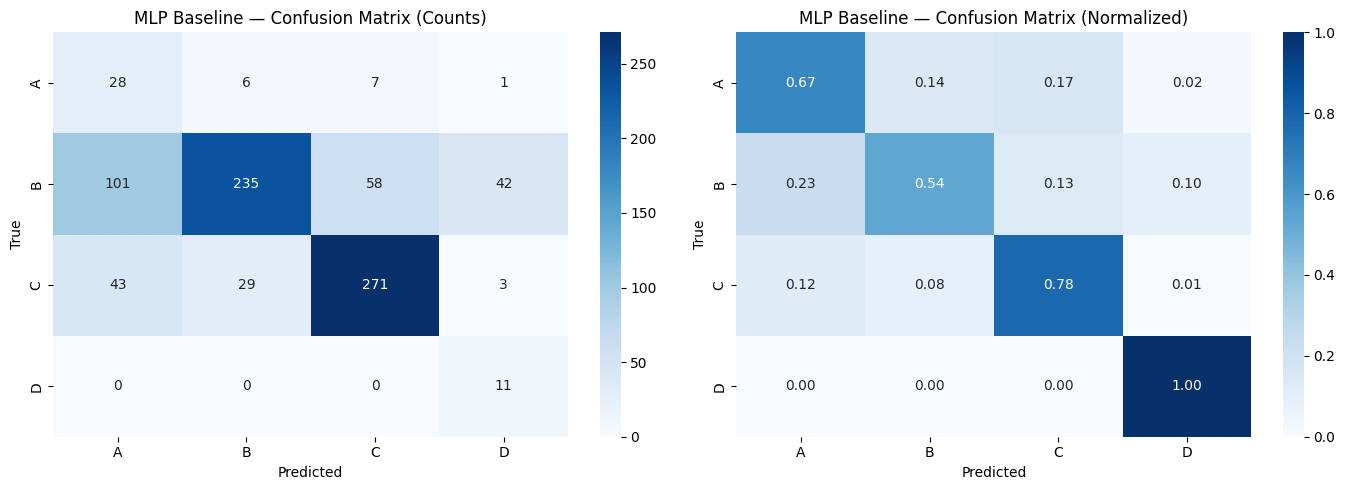

In [9]:
# Confusion Matrix
    # Compute confusion matrix to analyze misclassifications
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('MLP Baseline — Confusion Matrix (Counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('MLP Baseline — Confusion Matrix (Normalized)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{reports}/baseline_mlp_confusion_matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Visualization
Generates plots to visualize model performance or data distributions.

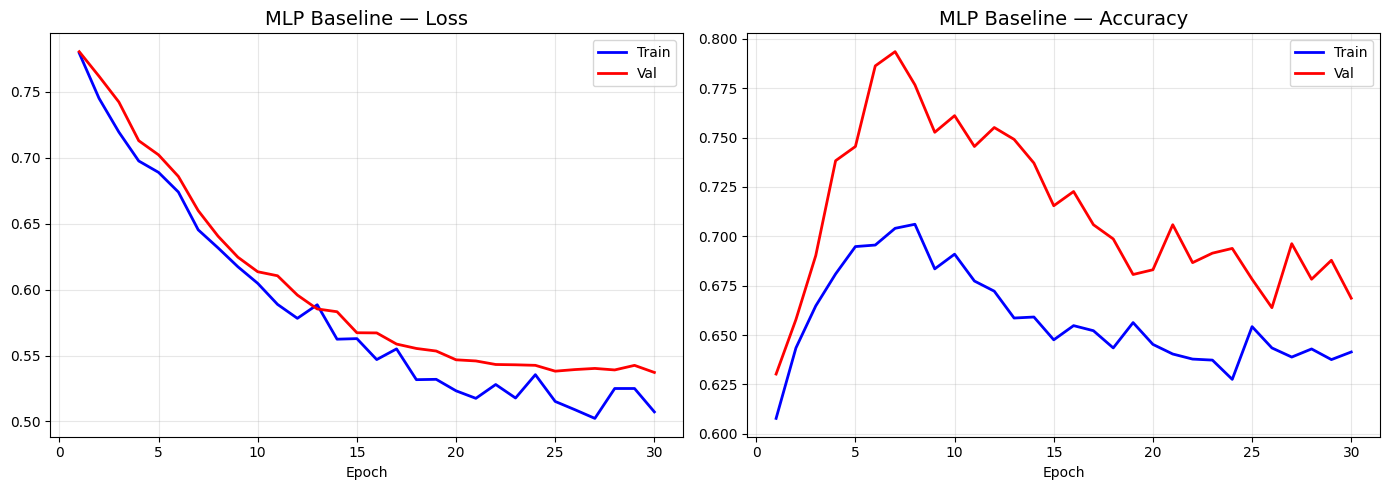

In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(mlp_history['train_loss'])+1)

axes[0].plot(epochs_range, mlp_history['train_loss'], 'b-', label='Train', lw=2)
axes[0].plot(epochs_range, mlp_history['val_loss'], 'r-', label='Val', lw=2)
axes[0].set_title('MLP Baseline — Loss', fontsize=14)
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, mlp_history['train_acc'], 'b-', label='Train', lw=2)
axes[1].plot(epochs_range, mlp_history['val_acc'], 'r-', label='Val', lw=2)
axes[1].set_title('MLP Baseline — Accuracy', fontsize=14)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f'{reports}/baseline_mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Save results for baseline model


In [11]:
# Save baseline results
baseline_results = {
    'model': 'MLP',
    'test_accuracy': test_acc,
    'y_test_pred': all_preds,
    'y_test_true': all_labels,
    'history': mlp_history,
}
with open(os.path.join(processed_data, 'baseline_results.pkl'), 'wb') as f:
    pickle.dump(baseline_results, f)

print(f'\nBaseline test accuracy: {test_acc:.4f}')
print('--- Ready for Notebook 04: Deep Learning Models ---')


Baseline test accuracy: 0.6527
--- Ready for Notebook 04: Deep Learning Models ---


## Visualizing Decision Boundaries in Latent Space
We use PCA to reduce the high-dimensional extracted features down to 2 dimensions, then we map the classifier's decision boundaries onto this 2D space to see how well it separates the subtypes.

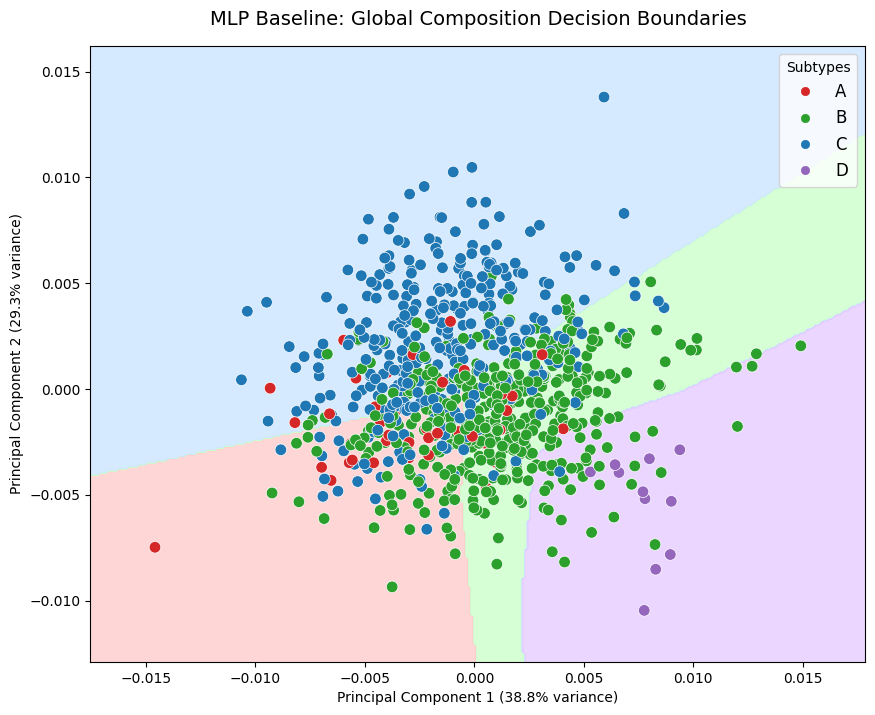

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Extract features for test set
mlp_model.eval()
features_list, labels_list = [], []

with torch.no_grad():
    for inputs, labels in test_dl:
        inputs = inputs.to(device)
        feats = mlp_model.feature_extractor(inputs)
        features_list.append(feats.cpu().numpy())
        labels_list.append(labels.numpy())

X_feats = np.concatenate(features_list)
y_true = np.concatenate(labels_list)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_feats)

# Dynamically calculate tight margins (10% padding instead of fixed 1.0)
margin_x = (X_pca[:, 0].max() - X_pca[:, 0].min()) * 0.1
margin_y = (X_pca[:, 1].max() - X_pca[:, 1].min()) * 0.1
x_min, x_max = X_pca[:, 0].min() - margin_x, X_pca[:, 0].max() + margin_x
y_min, y_max = X_pca[:, 1].min() - margin_y, X_pca[:, 1].max() + margin_y

# Use linspace for a guaranteed high-resolution 300x300 grid instead of fixed 0.1 steps
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Inverse transform meshgrid points back to original feature dimension
mesh_points_2d = np.c_[xx.ravel(), yy.ravel()]
mesh_points_nd = pca.inverse_transform(mesh_points_2d)
mesh_tensor = torch.tensor(mesh_points_nd, dtype=torch.float32).to(device)

# Predict on mesh points
with torch.no_grad():
    logits = mlp_model.classifier(mesh_tensor)
    preds = logits.argmax(dim=1).cpu().numpy()

Z = preds.reshape(xx.shape)

# Create highly distinct categorical colors
bg_cmap = ListedColormap(['#ffcccc', '#ccffcc', '#cce5ff', '#e5ccff']) # Soft pastel background
scatter_cmap = ListedColormap(['#d62728', '#2ca02c', '#1f77b4', '#9467bd']) # Strong foreground

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=bg_cmap)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=scatter_cmap, edgecolor='white', s=70, linewidth=0.5)

plt.title("MLP Baseline: Global Composition Decision Boundaries", fontsize=14, pad=15)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

# Add legend
handles, _ = scatter.legend_elements()
plt.legend(handles, [idx_to_label.get(i, f'Subtype {i}') for i in range(num_classes)], title="Subtypes", fontsize=12)
plt.savefig(os.path.join(reports, 'mlp_decision_boundaries.png'), bbox_inches='tight', dpi=300)
plt.show()
